In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, StratifiedKFold, train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/tese André mg feuc/datasets/stress perguntas dataset/Stress Dataset.csv'
df_raw = pd.read_csv(file_path)

# Consolidação das colunas duplicadas de ansiedade/tensão
col_orig = 'Have you been dealing with anxiety or tension recently?'
col_dup = 'Have you been dealing with anxiety or tension recently?.1'

if col_orig in df_raw.columns and col_dup in df_raw.columns:
    print("Consolidando colunas de ansiedade duplicadas...")
    # Criamos uma média ou apenas preenchemos se houver inconsistência
    df_raw[col_orig] = df_raw[[col_orig, col_dup]].mean(axis=1)
    df_raw = df_raw.drop(columns=[col_dup])

# Limpeza
df = df_raw.drop_duplicates().dropna().reset_index(drop=True)
print(f"\nShape original: {df_raw.shape} → ap???? limpeza: {df.shape}")

# Grupos de features (agora com apenas uma de ansiedade)
physical_features = [
    'Have you noticed a rapid heartbeat or palpitations?',
    'Have you been dealing with anxiety or tension recently?',
    'Have you been getting headaches more often than usual?',
    'Do you face any sleep problems or difficulties falling asleep?',
    'Have you been experiencing any illness or health issues?',
    'Have you gained/lost weight?'
]

subjective_features = [
    'Have you recently experienced stress in your life?',
    'Do you get irritated easily?',
    'Do you have trouble concentrating on your academic tasks?',
    'Have you been feeling sadness or low mood?',
    'Do you often feel lonely or isolated?',
    'Do you feel overwhelmed with your academic workload?',
    'Are you in competition with your peers, and does it affect you?',
    'Do you find that your relationship often causes you stress?',
    'Are you facing any difficulties with your professors or instructors?',
    'Is your working environment unpleasant or stressful?',
    'Do you struggle to find time for relaxation and leisure activities?',
    'Is your hostel or home environment causing you difficulties?',
    'Do you lack confidence in your academic performance?',
    'Do you lack confidence in your choice of academic subjects?',
    'Academic and extracurricular activities conflicting for you?',
    'Do you attend classes regularly?'
]

all_features = physical_features + subjective_features

# Target bin????rio
df['y_binary'] = df['Which type of stress do you primarily experience?'].apply(
    lambda x: 1 if 'Distress' in str(x) and 'Eustress' not in str(x) else 0
)

# MinMaxScaler
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(df[all_features]), columns=all_features)
y = df['y_binary']

# Divis?????? treino/teste
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nColunas finais processadas: {len(all_features)}")
print(f"Distress (1): {df['y_binary'].sum()} ({df['y_binary'].mean()*100:.1f}%)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Consolidando colunas de ansiedade duplicadas...

Shape original: (843, 25) → ap???? limpeza: (816, 25)

Colunas finais processadas: 22
Distress (1): 29 (3.6%)


In [11]:
from sklearn.feature_selection import RFE

def calcular_ranking_medio(X, y, estimador, n_splits=5):
    """
    Para cada fold, corre RFE até seleccionar 1 feature (ranking completo).
    Devolve a média dos rankings de todos os folds.
    """
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    rankings_por_fold = []

    for fold, (train_idx, _) in enumerate(cv.split(X, y)):
        X_fold = X.iloc[train_idx]
        y_fold = y.iloc[train_idx]

        rfe = RFE(estimator=estimador, n_features_to_select=1, step=1)
        rfe.fit(X_fold, y_fold)
        rankings_por_fold.append(rfe.ranking_)
        print(f"  Fold {fold+1}/5 concluído")

    return np.mean(rankings_por_fold, axis=0)

print("A calcular ranking médio — RandomForest...")
print("(pode demorar 2-3 minutos)")
ranking_rf = calcular_ranking_medio(
    X_scaled, y,
    RandomForestClassifier(n_estimators=100, random_state=42,
                           class_weight='balanced')
)

print("\nA calcular ranking médio — LogisticRegression...")
ranking_lr = calcular_ranking_medio(
    X_scaled, y,
    LogisticRegression(max_iter=1000, random_state=42,
                       class_weight='balanced')
)

# Tabela comparativa
df_rankings = pd.DataFrame({
    'Feature':            all_features,
    'Grupo':              ['Physical' if f in physical_features
                           else 'Subjective' for f in all_features],
    'Ranking RF (médio)': ranking_rf.round(2),
    'Ranking LR (médio)': ranking_lr.round(2),
})
df_rankings['Ranking combinado'] = (
    (df_rankings['Ranking RF (médio)'] +
     df_rankings['Ranking LR (médio)']) / 2
).round(2)
df_rankings['Diferença RF-LR'] = (
    df_rankings['Ranking RF (médio)'] -
    df_rankings['Ranking LR (médio)']
).round(2)

df_rankings = df_rankings.sort_values('Ranking combinado').reset_index(drop=True)
df_rankings.index += 1

print("\nTabela de rankings médios — RF vs LR (1 = mais importante)")
display(df_rankings)

print("\nFeatures onde os modelos mais discordam (|diferença| > 3):")
discordantes = df_rankings[df_rankings['Diferença RF-LR'].abs() > 3]
if len(discordantes) > 0:
    display(discordantes[['Feature', 'Grupo',
                           'Ranking RF (médio)', 'Ranking LR (médio)']])
else:
    print("Nenhuma discordância maior que 3 — modelos concordam bem.")

A calcular ranking médio — RandomForest...
(pode demorar 2-3 minutos)
  Fold 1/5 concluído
  Fold 2/5 concluído
  Fold 3/5 concluído
  Fold 4/5 concluído
  Fold 5/5 concluído

A calcular ranking médio — LogisticRegression...
  Fold 1/5 concluído
  Fold 2/5 concluído
  Fold 3/5 concluído
  Fold 4/5 concluído
  Fold 5/5 concluído

Tabela de rankings médios — RF vs LR (1 = mais importante)


,Feature,Grupo,Ranking RF (médio),Ranking LR (médio),Ranking combinado,Diferença RF-LR
1,Have you been dealing with anxiety or tension ...,Physical,1.0,1.6,1.3,-0.6
2,Do you get irritated easily?,Subjective,2.4,3.6,3.0,-1.2
3,Have you noticed a rapid heartbeat or palpitat...,Physical,4.0,4.0,4.0,0.0
4,Is your hostel or home environment causing you...,Subjective,9.0,2.4,5.7,6.6
5,Do you face any sleep problems or difficulties...,Physical,7.2,9.6,8.4,-2.4
6,Do you struggle to find time for relaxation an...,Subjective,7.2,10.2,8.7,-3.0
7,Academic and extracurricular activities confli...,Subjective,9.6,9.2,9.4,0.4
8,Have you been getting headaches more often tha...,Physical,7.8,12.2,10.0,-4.4
9,Is your working environment unpleasant or stre...,Subjective,12.4,7.6,10.0,4.8
10,Do you feel overwhelmed with your academic wor...,Subjective,14.4,8.6,11.5,5.8



Features onde os modelos mais discordam (|diferença| > 3):


,Feature,Grupo,Ranking RF (médio),Ranking LR (médio)
4,Is your hostel or home environment causing you...,Subjective,9.0,2.4
8,Have you been getting headaches more often tha...,Physical,7.8,12.2
9,Is your working environment unpleasant or stre...,Subjective,12.4,7.6
10,Do you feel overwhelmed with your academic wor...,Subjective,14.4,8.6
11,"Are you in competition with your peers, and do...",Subjective,13.2,9.8
15,Have you gained/lost weight?,Physical,16.0,11.2
16,Have you been experiencing any illness or heal...,Physical,9.8,17.4
17,Do you lack confidence in your choice of acade...,Subjective,10.4,17.2
18,Do you lack confidence in your academic perfor...,Subjective,14.4,18.2
20,Are you facing any difficulties with your prof...,Subjective,20.8,14.4


A calcular curva incremental — RandomForest...
  RF — 5/22 features
  RF — 10/22 features
  RF — 15/22 features
  RF — 20/22 features
  RF — 22/22 features

A calcular curva incremental — LogisticRegression...
  LR — 5/22 features
  LR — 10/22 features
  LR — 15/22 features
  LR — 20/22 features
  LR — 22/22 features

RF  — óptimo: 5 features | F1=0.633
LR  — óptimo: 16 features | F1=0.809


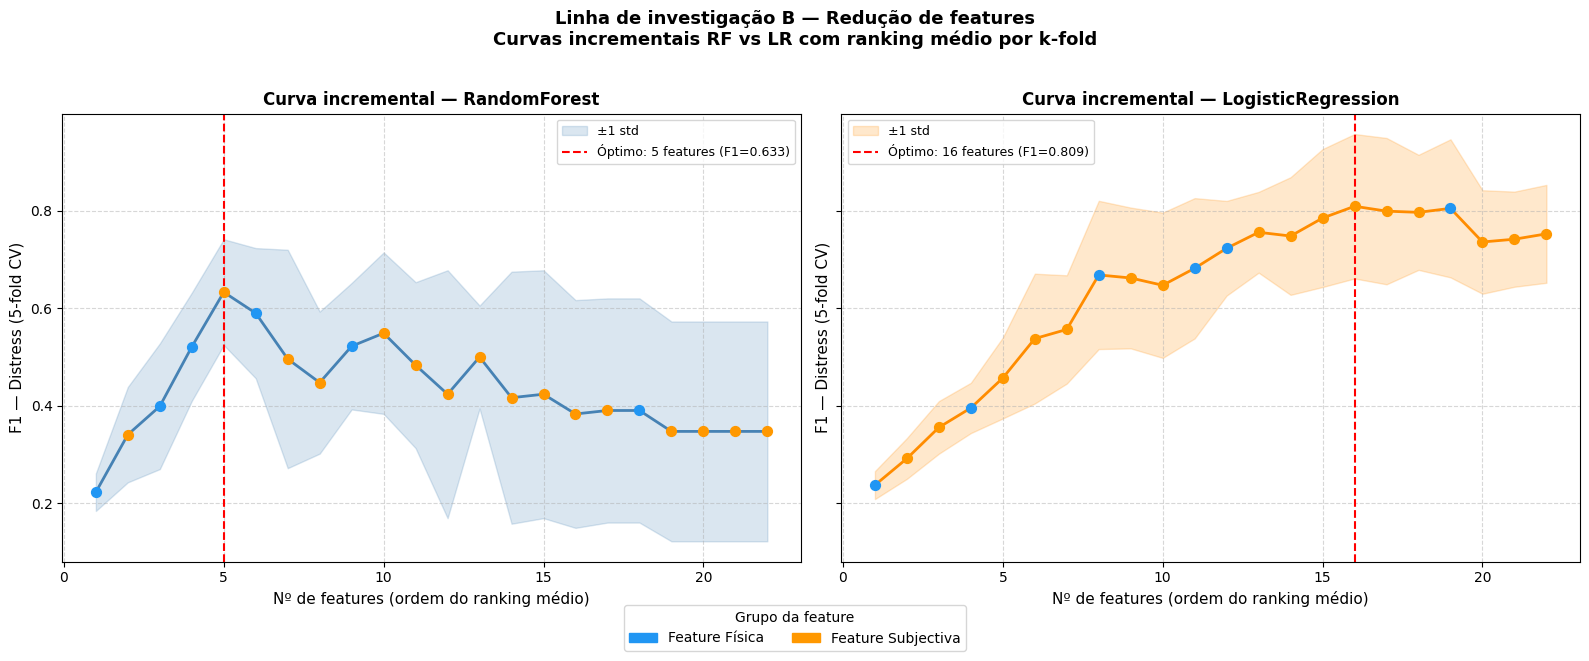

In [12]:
from sklearn.model_selection import cross_val_score

scorer = make_scorer(f1_score, zero_division=0)
cv_curva = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def curva_incremental(X_all, y, ranking_medio, estimador, all_features, nome):
    features_ordenadas = [all_features[i] for i in np.argsort(ranking_medio)]
    medias, stds = [], []

    for i in range(1, len(features_ordenadas) + 1):
        feats = features_ordenadas[:i]
        fold_scores = cross_val_score(
            estimador, X_all[feats], y,
            cv=cv_curva, scoring=scorer
        )
        medias.append(fold_scores.mean())
        stds.append(fold_scores.std())
        if i % 5 == 0 or i == len(features_ordenadas):
            print(f"  {nome} — {i}/{len(features_ordenadas)} features")

    return features_ordenadas, np.array(medias), np.array(stds)

print("A calcular curva incremental — RandomForest...")
feats_rf, scores_rf, std_rf = curva_incremental(
    X_scaled, y, ranking_rf,
    RandomForestClassifier(n_estimators=100, random_state=42,
                           class_weight='balanced'),
    all_features, 'RF'
)

print("\nA calcular curva incremental — LogisticRegression...")
feats_lr, scores_lr, std_lr = curva_incremental(
    X_scaled, y, ranking_lr,
    LogisticRegression(max_iter=1000, random_state=42,
                       class_weight='balanced'),
    all_features, 'LR'
)

# Número óptimo de features para cada modelo
opt_rf = int(np.argmax(scores_rf)) + 1
opt_lr = int(np.argmax(scores_lr)) + 1

print(f"\nRF  — óptimo: {opt_rf} features | F1={scores_rf.max():.3f}")
print(f"LR  — óptimo: {opt_lr} features | F1={scores_lr.max():.3f}")

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

configs = [
    (axes[0], feats_rf, scores_rf, std_rf, ranking_rf, 'RandomForest',       'steelblue',  opt_rf),
    (axes[1], feats_lr, scores_lr, std_lr, ranking_lr, 'LogisticRegression', 'darkorange', opt_lr),
]

for ax, feats, scores, std, ranking, titulo, cor, opt in configs:
    x = np.arange(1, len(scores) + 1)
    ax.plot(x, scores, color=cor, linewidth=2, zorder=3)
    ax.fill_between(x, scores - std, scores + std,
                    alpha=0.2, color=cor, label='±1 std')
    ax.axvline(opt, color='red', linestyle='--',
               label=f'Óptimo: {opt} features (F1={scores[opt-1]:.3f})')

    # Pontos coloridos por grupo
    for j, f in enumerate(feats):
        cor_ponto = '#2196F3' if f in physical_features else '#FF9800'
        ax.scatter(j + 1, scores[j], color=cor_ponto, zorder=5, s=50)

    ax.set_xlabel('Nº de features (ordem do ranking médio)', fontsize=11)
    ax.set_ylabel('F1 — Distress (5-fold CV)', fontsize=11)
    ax.set_title(f'Curva incremental — {titulo}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)

# Legenda global
from matplotlib.patches import Patch
fig.legend(
    handles=[Patch(color='#2196F3', label='Feature Física'),
             Patch(color='#FF9800', label='Feature Subjectiva')],
    loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.06),
    fontsize=10, title='Grupo da feature'
)
plt.suptitle('Linha de investigação B — Redução de features\n'
             'Curvas incrementais RF vs LR com ranking médio por k-fold',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('curva_incremental_RF_vs_LR.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Features óptimas de cada modelo
feats_opt_rf = feats_rf[:opt_rf]
feats_opt_lr = feats_lr[:opt_lr]

em_comum = set(feats_opt_rf) & set(feats_opt_lr)
so_rf    = set(feats_opt_rf) - set(feats_opt_lr)
so_lr    = set(feats_opt_lr) - set(feats_opt_rf)

print("=" * 60)
print(f"FEATURES ÓPTIMAS — RF: {opt_rf} | LR: {opt_lr}")
print("=" * 60)

print(f"\nEm comum ({len(em_comum)}) — consenso entre modelos:")
for f in sorted(em_comum):
    g = 'Physical' if f in physical_features else 'Subjective'
    print(f"  [{g}] {f}")

print(f"\nSó no RandomForest ({len(so_rf)}):")
for f in sorted(so_rf):
    g = 'Physical' if f in physical_features else 'Subjective'
    print(f"  [{g}] {f}")

print(f"\nSó na LogisticReg ({len(so_lr)}):")
for f in sorted(so_lr):
    g = 'Physical' if f in physical_features else 'Subjective'
    print(f"  [{g}] {f}")

# Contagem por grupo nas features óptimas
for modelo, feats_opt in [('RF', feats_opt_rf), ('LR', feats_opt_lr)]:
    n_phys = sum(1 for f in feats_opt if f in physical_features)
    n_subj = sum(1 for f in feats_opt if f in subjective_features)
    print(f"\n{modelo} — {len(feats_opt)} features óptimas: "
          f"{n_phys} físicas + {n_subj} subjectivas")

print("\n" + "=" * 60)
print("CONCLUSÃO PARA A TESE")
print("=" * 60)
print(f"O conjunto de {len(em_comum)} features em comum entre RF e LR")
print("representa o núcleo robusto de variáveis preditivas de Distress,")
print("independente da escolha do algoritmo.")
n_phys_comum = sum(1 for f in em_comum if f in physical_features)
n_subj_comum = sum(1 for f in em_comum if f in subjective_features)
print(f"Desse núcleo: {n_phys_comum} físicas + {n_subj_comum} subjectivas")
print("→ ambas as categorias contribuem para a detecção de Distress.")

FEATURES ÓPTIMAS — RF: 5 | LR: 16

Em comum (5) — consenso entre modelos:
  [Physical] Do you face any sleep problems or difficulties falling asleep?
  [Subjective] Do you get irritated easily?
  [Subjective] Do you struggle to find time for relaxation and leisure activities?
  [Physical] Have you been dealing with anxiety or tension recently?
  [Physical] Have you noticed a rapid heartbeat or palpitations?

Só no RandomForest (0):

Só na LogisticReg (11):
  [Subjective] Academic and extracurricular activities conflicting for you?
  [Subjective] Are you facing any difficulties with your professors or instructors?
  [Subjective] Are you in competition with your peers, and does it affect you?
  [Subjective] Do you feel overwhelmed with your academic workload?
  [Subjective] Do you have trouble concentrating on your academic tasks?
  [Subjective] Do you often feel lonely or isolated?
  [Subjective] Have you been feeling sadness or low mood?
  [Physical] Have you been getting headaches mor

A calcular curva incremental — RandomForest...
  RF — 5/22 features
  RF — 10/22 features
  RF — 15/22 features
  RF — 20/22 features
  RF — 22/22 features

A calcular curva incremental — LogisticRegression...
  LR — 5/22 features
  LR — 10/22 features
  LR — 15/22 features
  LR — 20/22 features
  LR — 22/22 features

RF  — óptimo: 5 features | F1=0.633
LR  — óptimo: 16 features | F1=0.809


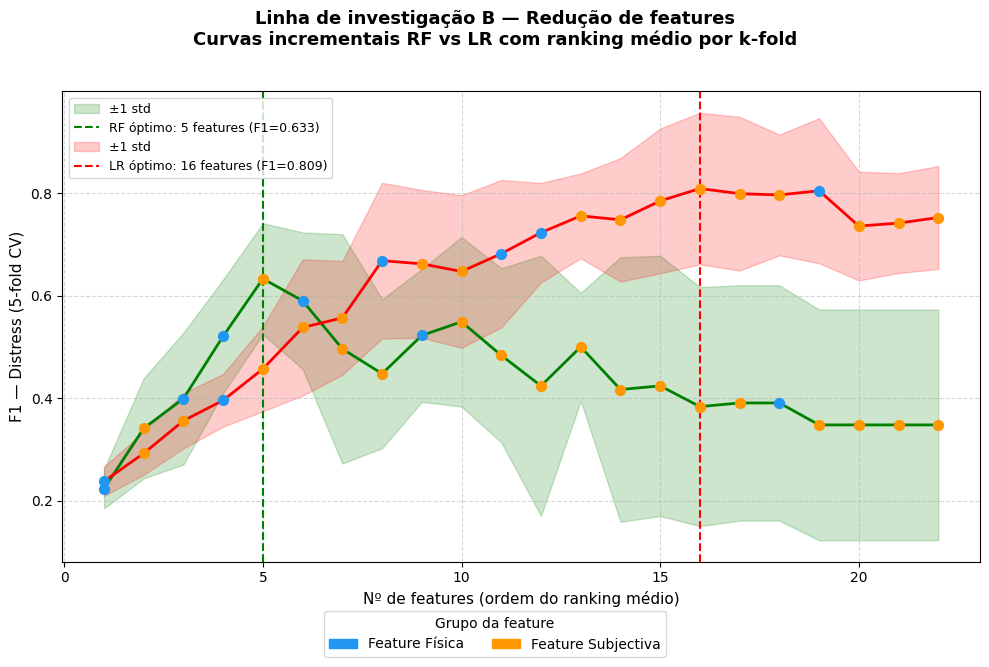

In [14]:
from sklearn.model_selection import cross_val_score

scorer = make_scorer(f1_score, zero_division=0)
cv_curva = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def curva_incremental(X_all, y, ranking_medio, estimador, all_features, nome):
    features_ordenadas = [all_features[i] for i in np.argsort(ranking_medio)]
    medias, stds = [], []

    for i in range(1, len(features_ordenadas) + 1):
        feats = features_ordenadas[:i]
        fold_scores = cross_val_score(
            estimador, X_all[feats], y,
            cv=cv_curva, scoring=scorer
        )
        medias.append(fold_scores.mean())
        stds.append(fold_scores.std())
        if i % 5 == 0 or i == len(features_ordenadas):
            print(f"  {nome} — {i}/{len(features_ordenadas)} features")

    return features_ordenadas, np.array(medias), np.array(stds)

print("A calcular curva incremental — RandomForest...")
feats_rf, scores_rf, std_rf = curva_incremental(
    X_scaled, y, ranking_rf,
    RandomForestClassifier(n_estimators=100, random_state=42,
                           class_weight='balanced'),
    all_features, 'RF'
)

print("\nA calcular curva incremental — LogisticRegression...")
feats_lr, scores_lr, std_lr = curva_incremental(
    X_scaled, y, ranking_lr,
    LogisticRegression(max_iter=1000, random_state=42,
                       class_weight='balanced'),
    all_features, 'LR'
)

# Número óptimo de features para cada modelo
opt_rf = int(np.argmax(scores_rf)) + 1
opt_lr = int(np.argmax(scores_lr)) + 1

print(f"\nRF  — óptimo: {opt_rf} features | F1={scores_rf.max():.3f}")
print(f"LR  — óptimo: {opt_lr} features | F1={scores_lr.max():.3f}")

# Gráfico
# fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

fig = plt.figure(figsize=(10, 6))

configs = [
    (plt.gca(), feats_rf, scores_rf, std_rf, ranking_rf, 'RandomForest',       'RF', 'green', opt_rf),
    (plt.gca(), feats_lr, scores_lr, std_lr, ranking_lr, 'LogisticRegression', 'LR', 'red',   opt_lr),
]

for ax, feats, scores, std, ranking, titulo, sigla, cor, opt in configs:
    x = np.arange(1, len(scores) + 1)
    ax.plot(x, scores, color=cor, linewidth=2, zorder=3)
    ax.fill_between(x, scores - std, scores + std,
                    alpha=0.2, color=cor, label='±1 std')
    ax.axvline(opt, color=cor, linestyle='--',
               label=f'{sigla} óptimo: {opt} features (F1={scores[opt-1]:.3f})')

    # Pontos coloridos por grupo
    for j, f in enumerate(feats):
        cor_ponto = '#2196F3' if f in physical_features else '#FF9800'
        ax.scatter(j + 1, scores[j], color=cor_ponto, zorder=5, s=50)

    ax.set_xlabel('Nº de features (ordem do ranking médio)', fontsize=11)
    ax.set_ylabel('F1 — Distress (5-fold CV)', fontsize=11)
    # ax.set_title(f'Curva incremental — {titulo}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)

# Legenda global
from matplotlib.patches import Patch
fig.legend(
    handles=[Patch(color='#2196F3', label='Feature Física'),
             Patch(color='#FF9800', label='Feature Subjectiva')],
    loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.07),
    fontsize=10, title='Grupo da feature'
)
plt.suptitle('Linha de investigação B — Redução de features\n'
             'Curvas incrementais RF vs LR com ranking médio por k-fold',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('curva_incremental_RF_vs_LR.png', dpi=150, bbox_inches='tight')
plt.show()